# Fase D · Ocho visualizaciones

Se ejecutan las mismas seis consultas de Fase C contra PostgreSQL. No depende de variables guardadas en otro notebook. Cada figura va seguida por un insight calculado con sus resultados.

> **Alcance:** análisis del archivo recibido. Todas sus fechas tienen día entre 1 y 12; no se conoce su cobertura completa ni se ha confirmado el CSV oficial. Se conservan filas idénticas por falta de un identificador de evento. `CANTIDAD` se suma; no equivale necesariamente al número de filas.

In [1]:
from pathlib import Path
import sys
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/proyecto.py').is_file()), None)
if RAIZ is None:
    raise RuntimeError('Abra el notebook desde la carpeta del proyecto o entrega/.')
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
import pandas as pd
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')
from src.proyecto import extraer, transformar, conectar, cargar, consultar

import matplotlib.pyplot as plt
from src.consultas import SQL
from src.visualizaciones import visualizar
motor = conectar()
resultados = [consultar(motor, sql) for sql in SQL]
motor.dispose()
salida = RAIZ / 'entrega/figuras'
salida.mkdir(exist_ok=True)

## V1. Serie temporal · Q1

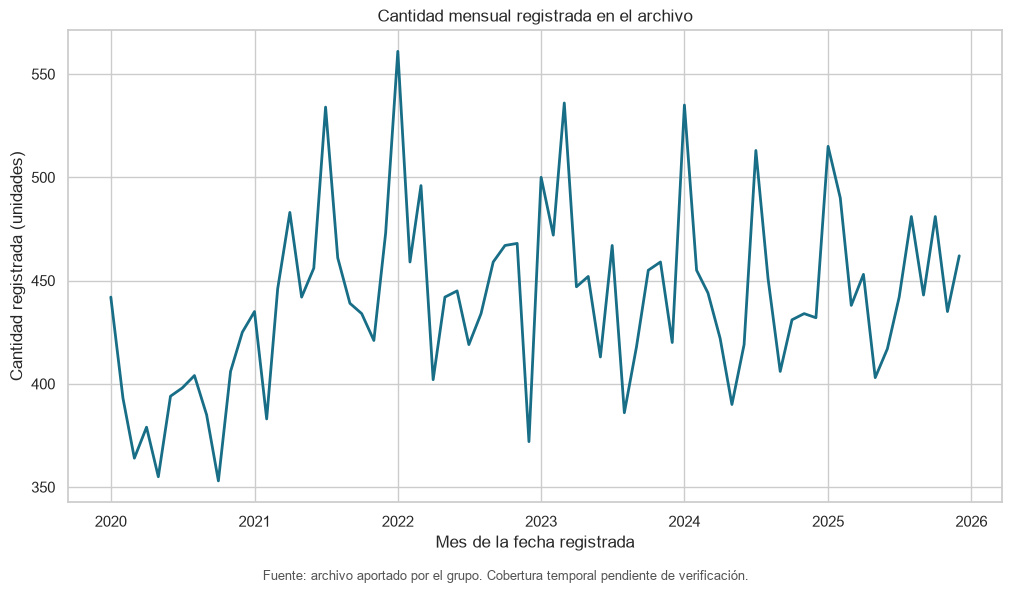

In [2]:
figura, insight = visualizar(1, resultados)
figura.savefig(salida / 'v01.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [3]:
display(Markdown("**Insight:** " + insight))

**Insight:** El archivo contiene 72 meses y suma 31,746 unidades de CANTIDAD. El máximo mensual es 561 en 2022-01; el cambio calculado describe el archivo, cuya cobertura de días es anómala.

## V2. Comparación categórica · Q2

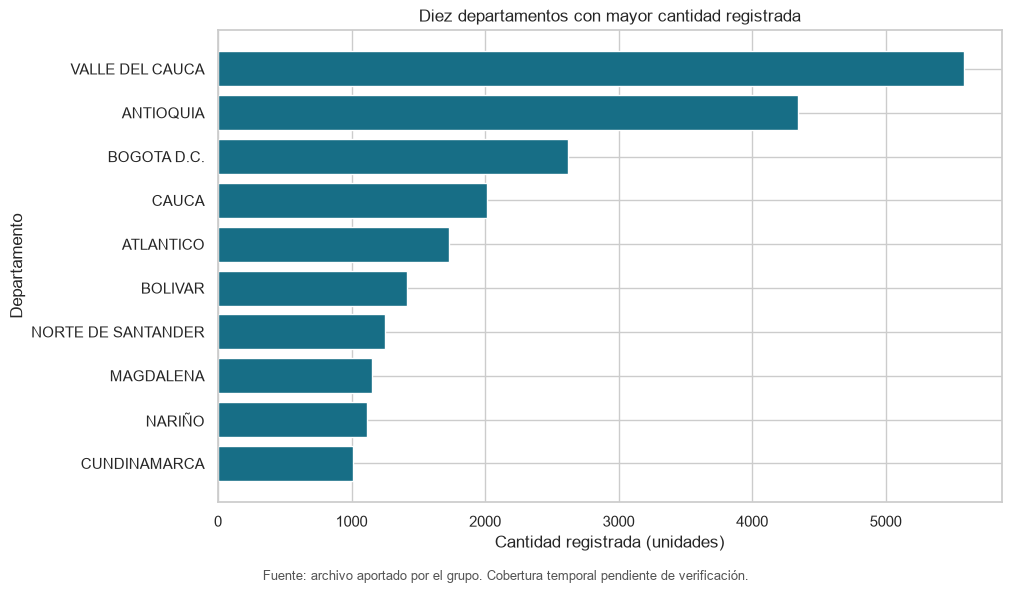

In [4]:
figura, insight = visualizar(2, resultados)
figura.savefig(salida / 'v02.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [5]:
display(Markdown("**Insight:** " + insight))

**Insight:** VALLE DEL CAUCA ocupa el primer lugar con 5,589 unidades (17.61% del archivo). Son cantidades absolutas; sin población y cobertura verificadas no representan tasas de riesgo.

## V3. Comparación por año y zona · Q3

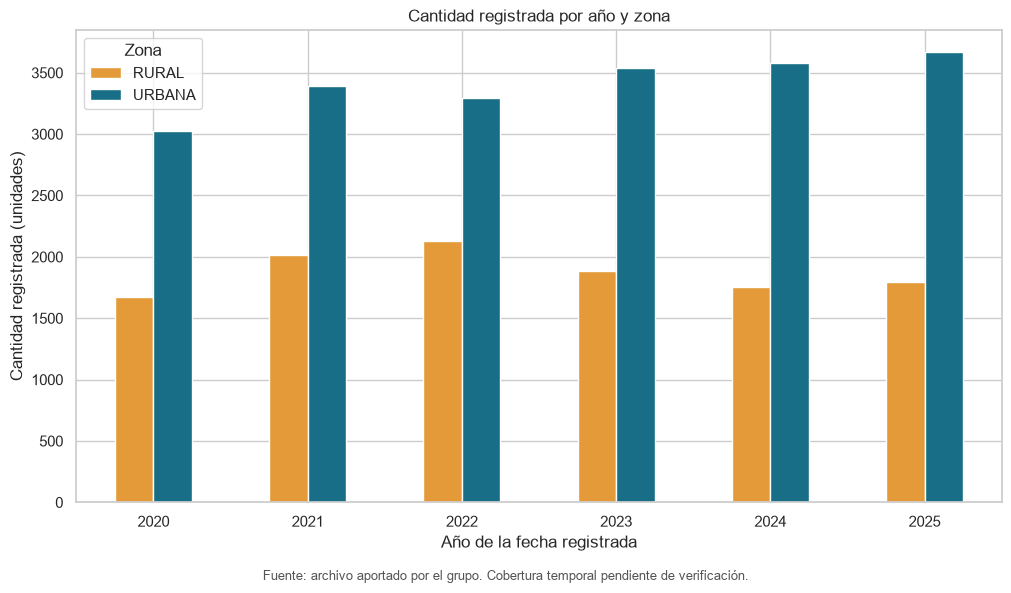

In [6]:
figura, insight = visualizar(3, resultados)
figura.savefig(salida / 'v03.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [7]:
display(Markdown("**Insight:** " + insight))

**Insight:** La zona URBANA concentra 20,497 unidades (64.57%). Las comparaciones anuales están condicionadas por la cobertura de fechas del archivo.

## V4. Comparación categórica · Q4

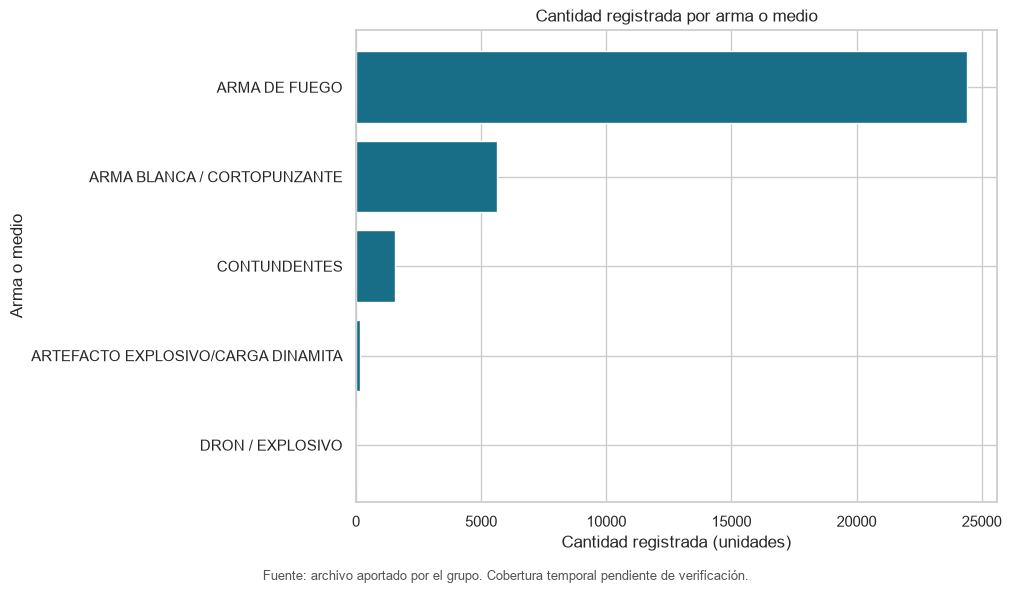

In [8]:
figura, insight = visualizar(4, resultados)
figura.savefig(salida / 'v04.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [9]:
display(Markdown("**Insight:** " + insight))

**Insight:** ARMA DE FUEGO concentra 24,397 unidades (76.85%). La separación por sexo describe registros, sin establecer causalidad ni riesgo individual.

## V5. Relación bivariada · Q5

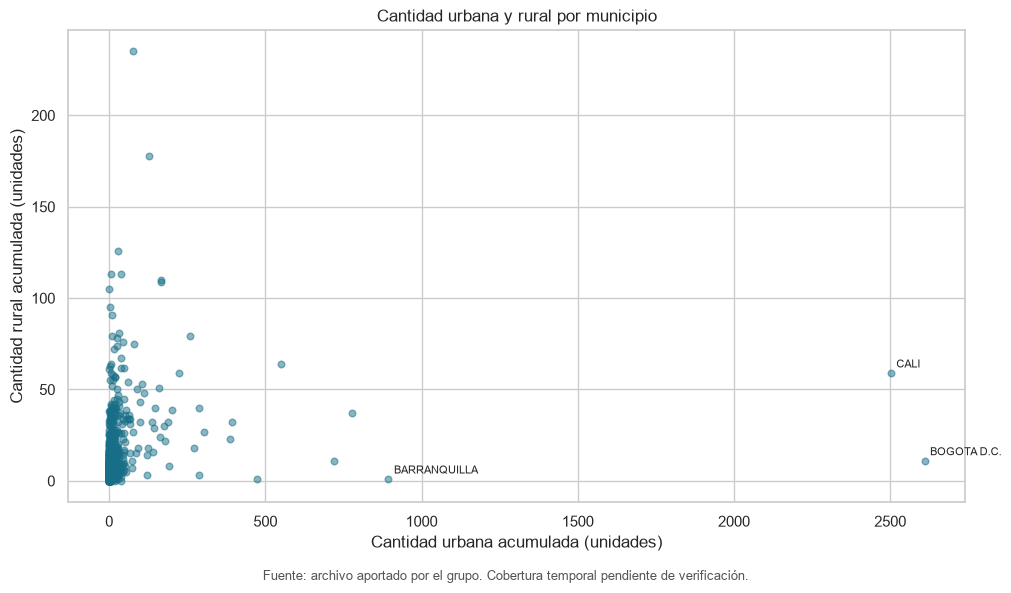

In [10]:
figura, insight = visualizar(5, resultados)
figura.savefig(salida / 'v05.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [11]:
display(Markdown("**Insight:** " + insight))

**Insight:** Se observan 936 municipios; BOGOTA D.C. reúne 2,621 unidades. La correlación de Pearson urbana-rural es 0.163; está afectada por tamaño municipal, cobertura y valores extremos.

## V6. Distribución univariada con KDE · Q6

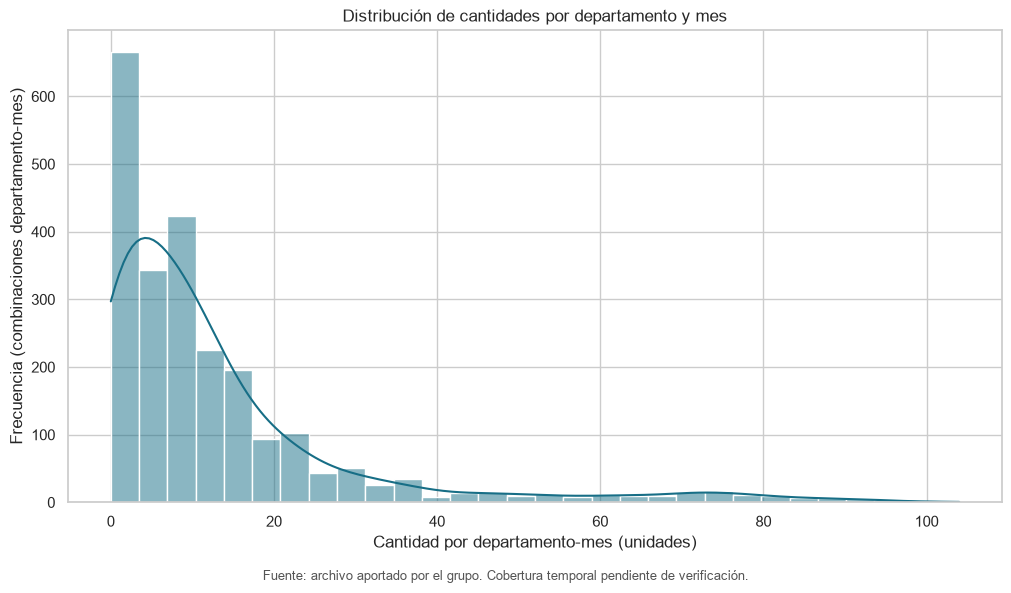

In [12]:
figura, insight = visualizar(6, resultados)
figura.savefig(salida / 'v06.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [13]:
display(Markdown("**Insight:** " + insight))

**Insight:** La cuadrícula contiene 2376 combinaciones departamento-mes; su mediana es 8.0 unidades. Los 281 ceros significan ausencia de filas en el archivo para esa combinación, no ausencia confirmada de homicidios.

## V7. Distribución comparativa · Q6, selección Q2

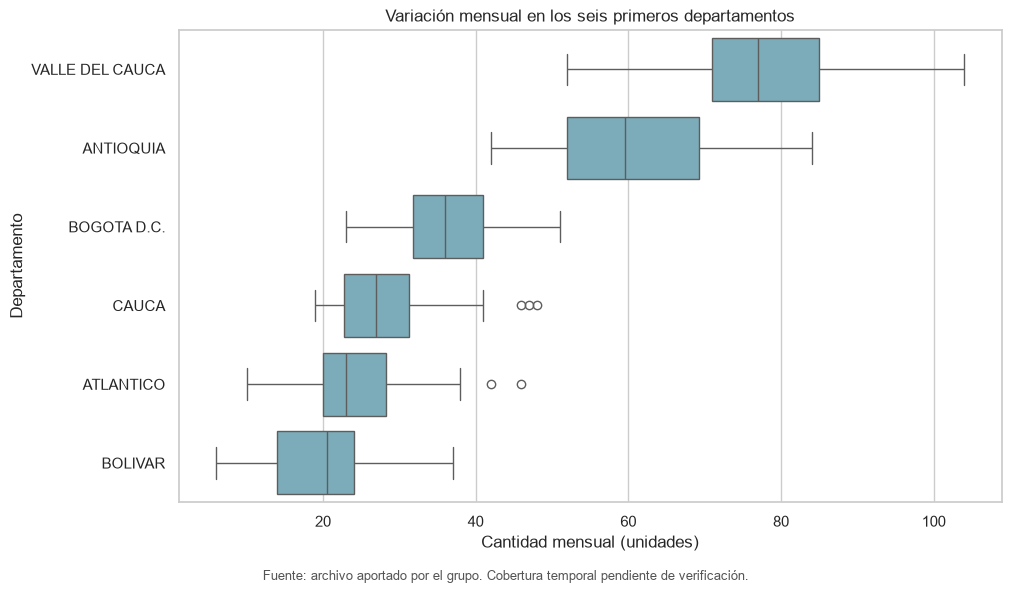

In [14]:
figura, insight = visualizar(7, resultados)
figura.savefig(salida / 'v07.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [15]:
display(Markdown("**Insight:** " + insight))

**Insight:** Entre estos seis departamentos, VALLE DEL CAUCA tiene la mayor mediana mensual: 77.0 unidades. Las cajas muestran dispersión y los puntos extremos no se eliminan; todos provienen de Q6.

## V8. Comparación año-sexo · Q3

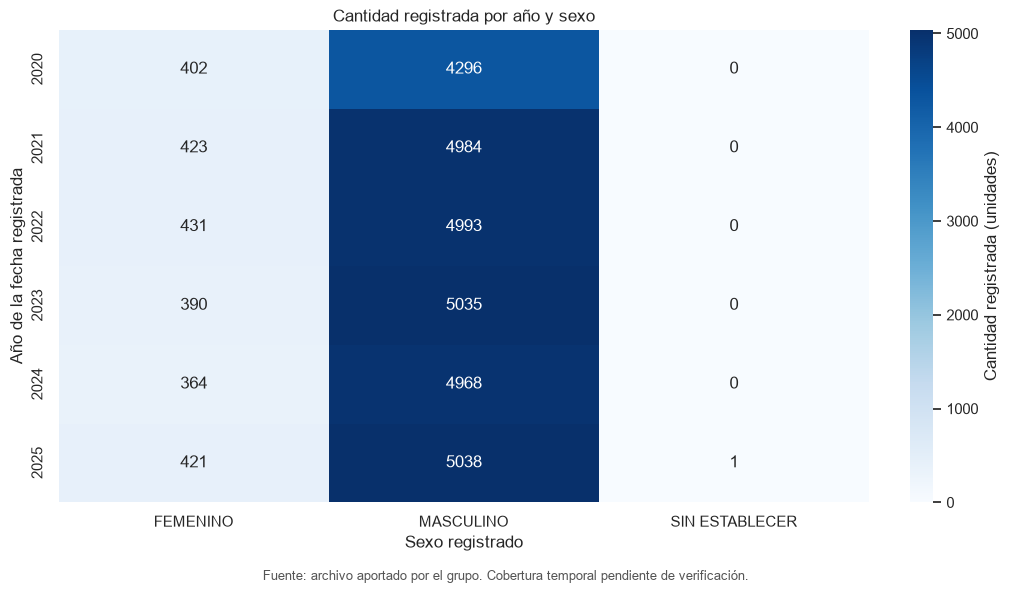

In [16]:
figura, insight = visualizar(8, resultados)
figura.savefig(salida / 'v08.png', dpi=170, bbox_inches='tight')
plt.show()
plt.close(figura)

In [17]:
display(Markdown("**Insight:** " + insight))

**Insight:** La categoría MASCULINO reúne 29,314 unidades (92.34%). Se conserva SIN ESTABLECER como categoría explícita; el gráfico no estima riesgo por sexo.